# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [55]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [57]:
# mostrar las primeras 5 filas de plans
print("=== DATASET PLANS ===")
print(f"Forma: {plans.shape}")
print(f"Columnas: {list(plans.columns)}")
print(plans.head())

=== DATASET PLANS ===
Forma: (2, 8)
Columnas: ['plan_name', 'messages_included', 'gb_per_month', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute']
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [58]:
# mostrar las primeras 5 filas de users
print("\n=== DATASET USERS ===")
print(f"Forma: {users.shape}")
print(f"Columnas: {list(users.columns)}")
print(users.head())


=== DATASET USERS ===
Forma: (4000, 8)
Columnas: ['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date']
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [59]:
# mostrar las primeras 5 filas de usage
print("\n=== DATASET USAGE ===")
print(f"Forma: {usage.shape}")
print(f"Columnas: {list(usage.columns)}")
print(usage.head())


=== DATASET USAGE ===
Forma: (40000, 6)
Columnas: ['id', 'user_id', 'type', 'date', 'duration', 'length']
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [60]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [61]:
# inspección de plans con .info()
print("\n🔹 DATASET PLANS:")
print(f"Dimensiones (filas, columnas): {plans.shape}")
print("\nInformación detallada:")
plans.info()

print("\n" + "="*30)



🔹 DATASET PLANS:
Dimensiones (filas, columnas): (2, 8)

Información detallada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes



In [62]:
# inspección de users con .info()
print("\n🔹 DATASET USERS:")
print(f"Dimensiones (filas, columnas): {users.shape}")
print("\nInformación detallada:")
users.info()

print("\n" + "="*30)


🔹 DATASET USERS:
Dimensiones (filas, columnas): (4000, 8)

Información detallada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB



In [63]:
# inspección de usage con .info()
print("\n🔹 DATASET USAGE:")
print(f"Dimensiones (filas, columnas): {usage.shape}")
print("\nInformación detallada:")
usage.info()


🔹 DATASET USAGE:
Dimensiones (filas, columnas): (40000, 6)

Información detallada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [64]:

# cantidad de nulos para users
print(users.isnull().sum())# Cantidad de valores nulos)
print(users.isnull().sum() / len(users))# Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [65]:
#cantidad de nulos para usage
usage.isnull().sum()

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


**DATASET USERS - Análisis detallado:**

### Valores Nulos encontrados:
- city: 469 nulos (11.725% = 11.73%)
- churn_date: 3534 nulos (88.350% = 88.35%)
- Resto de columnas: 0 nulos (0%)

1. churn_date (3534 nulos = 88.35%): IGNORAR
-Justificación: Los nulos = clientes activos (lógica de negocio), hay una alta retencion de clientes solo el 11.65% de tasa de abandono

2. city (469 nulos = 11.73%): IMPUTAR 
- Analisis: 11.73% es significativo, pero manejable
- Sugerencia: Imputar con la ciudad más frecuente

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.
 

- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [66]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves. Tenemos la misma cantidad de valores 40 000 en ambas columnas lo que indica que estan bien formadas es decir no tenemos usuarios sin identificador y viceversa 
- Las columnas ...

In [67]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"--- Análisis de la columna: {columna} ---")
    print(f"Valores únicos: {users[columna].nunique()}")
    print(f"Valores nulos: {users[columna].isnull().sum()}")
    print("\nDistribución de valores:")
    print(users[columna].value_counts())
    print("\nPorcentajes:")
    print(users[columna].value_counts(normalize=True) * 100)
    print("\n" + "="*50 + "\n")


--- Análisis de la columna: city ---
Valores únicos: 7
Valores nulos: 469

Distribución de valores:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Porcentajes:
Bogotá      22.883036
CDMX        20.674030
Medellín    17.445483
GDL         12.744265
Cali        12.007930
MTY         11.526480
?            2.718777
Name: city, dtype: float64


--- Análisis de la columna: plan ---
Valores únicos: 2
Valores nulos: 0

Distribución de valores:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Porcentajes:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64




- La columna `city` ...
- La columna `plan` ...

In [68]:
# explorar columna categórica de usage
#usage['type'].value_counts() # completa el código
print("Columnas en usage:")
print(usage.columns.tolist())
print("\nTipos de datos:")
print(usage.dtypes)

Columnas en usage:
['id', 'user_id', 'type', 'date', 'duration', 'length']

Tipos de datos:
id            int64
user_id       int64
type         object
date         object
duration    float64
length      float64
dtype: object


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [69]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')# completa el código

In [70]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [71]:
# Revisar los años presentes en `reg_date` de users
years_in_reg_date = users['reg_date'].dt.year.unique()
print("Años únicos en reg_date:")
print(sorted(years_in_reg_date))

Años únicos en reg_date:
[2022, 2023, 2024, 2026]


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
La salida no tiene sentido para el negocio pues los valores no son consistentes, existen saltos bruscos entre años (2024-2026), culminan en 2026 en el enunciado aparece que es un analisis hasta 2024.

In [72]:
# Revisar los años presentes en `date` de usage
years_in_usage_date = usage['date'].dt.year.unique()
print("Años únicos en date (usage):")
print(sorted(years_in_usage_date))

Años únicos en date (usage):
[2024.0, nan]


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [73]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [74]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace("?", pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [75]:
import datetime

# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Definir la fecha de hoy
today = datetime.date.today()

# Marcar fechas futuras como NaT (Not a Time) - correcto para datetime
users.loc[users['reg_date'].dt.date > today, 'reg_date'] = pd.NaT

# Verificar cambios
print("Fechas futuras encontradas:", (users['reg_date'].dt.date > today).sum())
print("Valores NaT después del cambio:", users['reg_date'].isna().sum())

Fechas futuras encontradas: 0
Valores NaT después del cambio: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [76]:
# Verificación MAR en usage (Missing At Random) para duration
# Calcular la proporción de valores faltantes en duration por tipo de comunicación
mar_verification = usage['duration'].isna().groupby(usage['type']).mean()

print("Proporción de valores faltantes en 'duration' por tipo:")
print(mar_verification)
print()

# Interpretación automática
print("Interpretación:")
for tipo, proporcion in mar_verification.items():
    print(f"- {tipo}: {proporcion:.1%} de valores faltantes")

# Verificar si hay diferencias significativas
diferencia_max = mar_verification.max() - mar_verification.min()
print(f"\nDiferencia máxima entre grupos: {diferencia_max:.1%}")

if diferencia_max > 0.05:  # Si la diferencia es mayor al 5%
    print(" CONCLUSIÓN: Los faltantes en 'duration' son MAR")
    print("   → Dependen del tipo de comunicación")
    print("   → Recomendación: Imputar por separado según 'type'")
else:
    print(" CONCLUSIÓN: Los faltantes en 'duration' son MCAR") 
    print("   → No dependen del tipo de comunicación")
    print("   → Recomendación: Imputación global es segura")

Proporción de valores faltantes en 'duration' por tipo:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64

Interpretación:
- call: 0.0% de valores faltantes
- text: 99.9% de valores faltantes

Diferencia máxima entre grupos: 99.9%
 CONCLUSIÓN: Los faltantes en 'duration' son MAR
   → Dependen del tipo de comunicación
   → Recomendación: Imputar por separado según 'type'


In [77]:
# Verificación MAR en usage (Missing At Random) para length
mar_verification_length = usage['length'].isna().groupby(usage['type']).mean()

print("Proporción de valores faltantes en 'length' por tipo:")
print(mar_verification_length)
print()

# Interpretación detallada
print("Interpretación:")
for tipo, proporcion in mar_verification_length.items():
    print(f"- {tipo}: {proporcion:.1%} de valores faltantes")

# Verificar si hay diferencias significativas
diferencia_max_length = mar_verification_length.max() - mar_verification_length.min()
print(f"\nDiferencia máxima entre grupos: {diferencia_max_length:.1%}")

if diferencia_max_length > 0.05:  # Si la diferencia es mayor al 5%
    print(" CONCLUSIÓN: Los faltantes en 'length' son MAR")
    print("   → Dependen del tipo de comunicación")
    print("   → Justificación: Es lógico que solo los mensajes tengan longitud")
else:
    print(" CONCLUSIÓN: Los faltantes en 'length' son MCAR") 
    print("   → No dependen del tipo de comunicación")
    print("   → Revisar si hay problemas en la recolección de datos")

Proporción de valores faltantes en 'length' por tipo:
type
call    0.99933
text    0.00000
Name: length, dtype: float64

Interpretación:
- call: 99.9% de valores faltantes
- text: 0.0% de valores faltantes

Diferencia máxima entre grupos: 99.9%
 CONCLUSIÓN: Los faltantes en 'length' son MAR
   → Dependen del tipo de comunicación
   → Justificación: Es lógico que solo los mensajes tengan longitud


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [78]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
#usage_agg = usage ... reset_index()
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # suma todos los 1s = total de mensajes
    'is_call': 'sum',      # suma todos los 1s = total de llamadas  
    'duration': 'sum'      # suma total de minutos de llamadas
}).reset_index()


In [79]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'total_messages', 'total_calls', 'total_call_minutes']
# observar resultado
usage_agg.head(3)

,user_id,total_messages,total_calls,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [80]:
# Combinar la tabla agregada con el dataset de usuarios
#user_profile = 
#user_profile.head(5)
# PASO 1: Combinar usage_agg con users para crear user_profile
user_profile = users.merge(usage_agg, on='user_id', how='left')

# PASO 2: Verificar el resultado
print("=== INFORMACIÓN DE LA COMBINACIÓN ===")
print(f"Filas en users: {len(users)}")
print(f"Filas en usage_agg: {len(usage_agg)}")
print(f"Filas en user_profile: {len(user_profile)}")

print("\n=== PRIMERAS 5 FILAS DEL RESULTADO ===")
print(user_profile.head())

=== INFORMACIÓN DE LA COMBINACIÓN ===
Filas en users: 4000
Filas en usage_agg: 3999
Filas en user_profile: 4000

=== PRIMERAS 5 FILAS DEL RESULTADO ===
   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0      <NA> 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  total_messages  total_calls  total_call_minutes  
0   Basico        NaN             7.0          3.0               23.70  
1   Basico        NaN             5.0         10.0               33.18  
2   Basico        NaN             5.0          2.0               10.74  
3  Premium        NaN            11.0          3.0                8.9

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [81]:
# Resumen estadístico de las columnas numéricas
numeric_columns = usage_agg.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Columnas numéricas identificadas: {numeric_columns}")
print()

# Resumen estadístico completo
estadisticas_numericas = usage_agg[numeric_columns].describe()
print("Estadísticas descriptivas:")
print(estadisticas_numericas.round(2))
print()

# Información adicional útil para el negocio
print("=== ANÁLISIS ADICIONAL ===")
for col in numeric_columns:
    if col != 'user_id':  # Excluir user_id del análisis
        print(f"\n {col.upper()}:")
        print(f"   • Promedio: {usage_agg[col].mean():.2f}")
        print(f"   • Mediana: {usage_agg[col].median():.2f}")
        print(f"   • Rango: {usage_agg[col].min():.2f} - {usage_agg[col].max():.2f}")
        print(f"   • Usuarios con valor 0: {(usage_agg[col] == 0).sum()} ({(usage_agg[col] == 0).mean()*100:.1f}%)")

Columnas numéricas identificadas: ['user_id', 'total_messages', 'total_calls', 'total_call_minutes']

Estadísticas descriptivas:
        user_id  total_messages  total_calls  total_call_minutes
count   3999.00         3999.00      3999.00             3999.00
mean   11999.73            5.52         4.48               23.32
std     1154.90            2.36         2.14               18.17
min    10000.00            0.00         0.00                0.00
25%    10999.50            4.00         3.00               11.12
50%    12000.00            5.00         4.00               19.78
75%    12999.50            7.00         6.00               31.42
max    13999.00           17.00        15.00              155.69

=== ANÁLISIS ADICIONAL ===

 TOTAL_MESSAGES:
   • Promedio: 5.52
   • Mediana: 5.00
   • Rango: 0.00 - 17.00
   • Usuarios con valor 0: 18 (0.5%)

 TOTAL_CALLS:
   • Promedio: 4.48
   • Mediana: 4.00
   • Rango: 0.00 - 15.00
   • Usuarios con valor 0: 41 (1.0%)

 TOTAL_CALL_MINUTES:
 

In [82]:
# Distribución porcentual del tipo de plan
print(" CONTEOS Y PORCENTAJES:")
plan_counts = users['plan'].value_counts()
plan_percentages = users['plan'].value_counts(normalize=True) * 100

# Crear tabla combinada
plan_distribution = pd.DataFrame({
    'Cantidad': plan_counts,
    'Porcentaje': plan_percentages.round(2)
})

print(plan_distribution)
print()

# Información adicional
print("=== ANÁLISIS DETALLADO ===")
total_users = len(users)
print(f"Total de usuarios: {total_users}")

for plan in users['plan'].unique():
    count = (users['plan'] == plan).sum()
    percentage = (count / total_users) * 100
    print(f"\n Plan {plan}:")
    print(f"   • Usuarios: {count}")
    print(f"   • Porcentaje: {percentage:.2f}%")


 CONTEOS Y PORCENTAJES:
         Cantidad  Porcentaje
Basico       2595       64.88
Premium      1405       35.12

=== ANÁLISIS DETALLADO ===
Total de usuarios: 4000

 Plan Basico:
   • Usuarios: 2595
   • Porcentaje: 64.88%

 Plan Premium:
   • Usuarios: 1405
   • Porcentaje: 35.12%


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

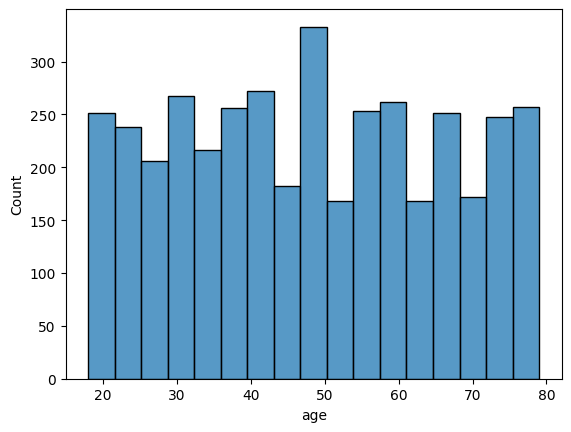

In [83]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users, x='age')
plt.show()

💡Insights: 
- Distribución ...
- El maor numero de clientes se encuentra entre 46 y 50 anos
- Existe una ligera diferencia entre los clientes entre 20 y 50 y de 50 a 80. Lo que indica que a pesar de ser una tecnologia orientada al publico sobre los 20 a 50, la compania, esta guiando bien las campanas comerciales.

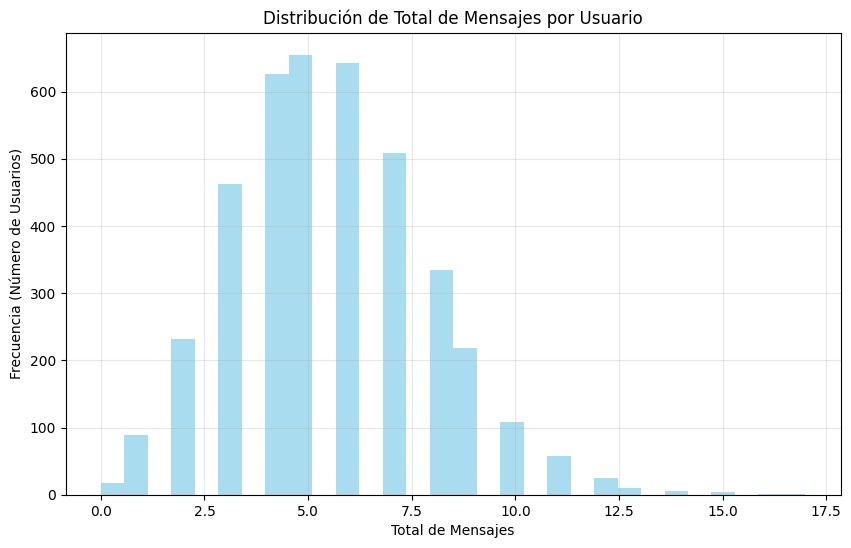

In [105]:
# Histograma para visualizar la cant_mensajes
#plt.figure(figsize=(10, 6))
#sns.histplot(data=users_agg, x='total_messages', bins=30, kde=True)
#plt.title('Distribución de la Cantidad de Mensajes por Usuario')
#plt.xlabel('Cantidad de Mensajes')
#plt.ylabel('Frecuencia')
#plt.show()
#%who_ls
#%who_ls DataFrame
#print("Columnas numéricas disponibles:")
#print(numeric_columns)
#print("Variables disponibles:", [var for var in dir() if not var.startswith('_')])
#print("Columnas en usage_agg:")
#print(usage_agg.columns.tolist())
#print("\nPrimeras filas:")
#print(usage_agg.head())
plt.figure(figsize=(10, 6))
plt.hist(usage_agg['total_messages'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribución de Total de Mensajes por Usuario')
plt.xlabel('Total de Mensajes')
plt.ylabel('Frecuencia (Número de Usuarios)')
plt.grid(True, alpha=0.3)
plt.show()

💡Insights: 
Hay un sesgo a la derecha en la distribución lo que significa que:

  La mayoría de usuarios envían pocas cantidades de mensajes
     Hay una "cola larga" hacia la derecha con algunos usuarios que envían muchos más mensajes
    La media será mayor que la mediana debido a esos valores extremos
    Interpretación del negocio: Esto nos dice que el comportamiento de los usuarios de telecomunicaciones, cada vez es menos inusual el envio de mensajes de texto, sprofieren envios por aplicaciones externas como whatsapp, telegram o teams.
    Valores extremos: Se observa algunos usuarios con cantidades muy altas de mensajes, lo que podrían ser outliers o usuarios con patrones de uso muy diferentes. O que se estan utilizando para campanas publicitarias.

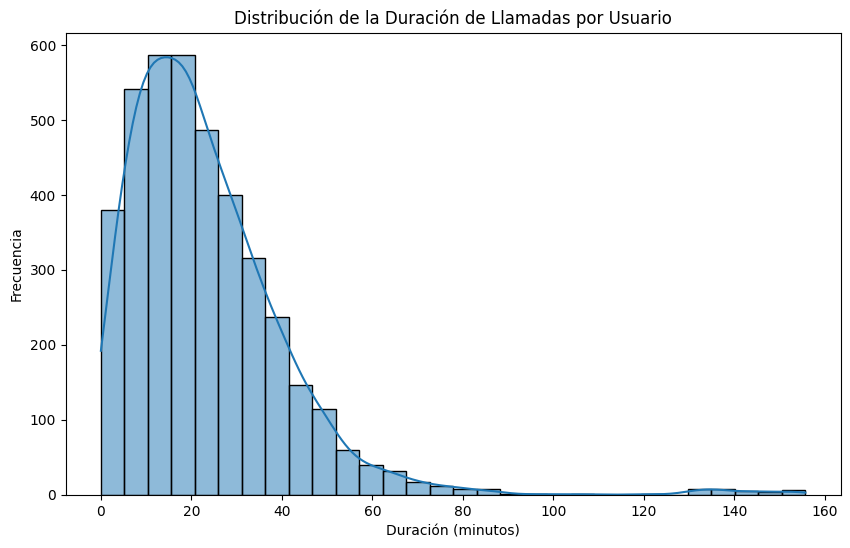

Estadísticas de duración de llamadas:
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: duration, dtype: float64

Usuarios con más de 100 minutos: 31


In [46]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='duration', bins=30, kde=True)
plt.title('Distribución de la Duración de Llamadas por Usuario')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')
plt.show()
print("Estadísticas de duración de llamadas:")
print(user_profile['duration'].describe())
print(f"\nUsuarios con más de 100 minutos: {(user_profile['duration'] > 100).sum()}")


💡Insights: 
- Distribución ...
      Concentración masiva en 0-30 minutos: Esto sugiere que la mayoría de usuarios tienen llamadas cortas o moderadas. Lo que coincide con la realidad.
    Cola larga a la derecha: Indica que hay algunos usuarios con duraciones de llamada muy altas (posiblemente usuarios de negocio como call-center, help-desk, o personas que hacen llamadas muy largas)

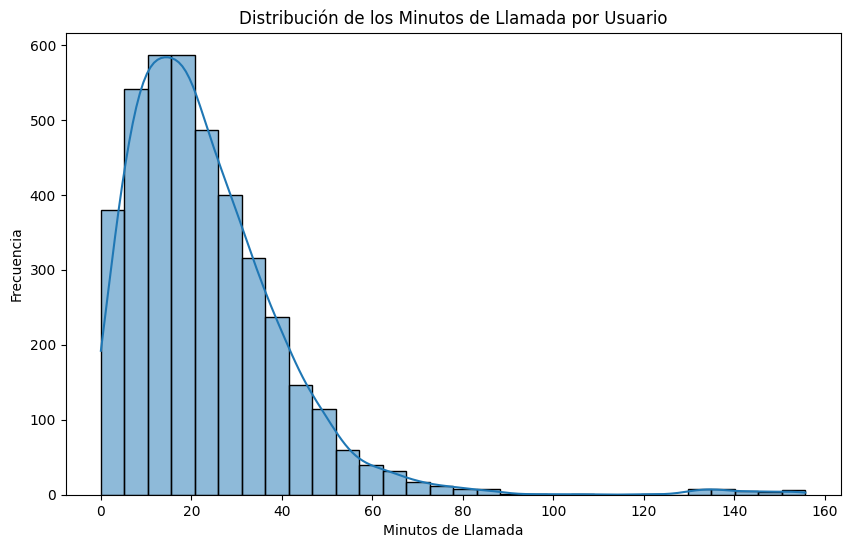

In [51]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='duration', bins=30, kde=True)
plt.title('Distribución de los Minutos de Llamada por Usuario')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

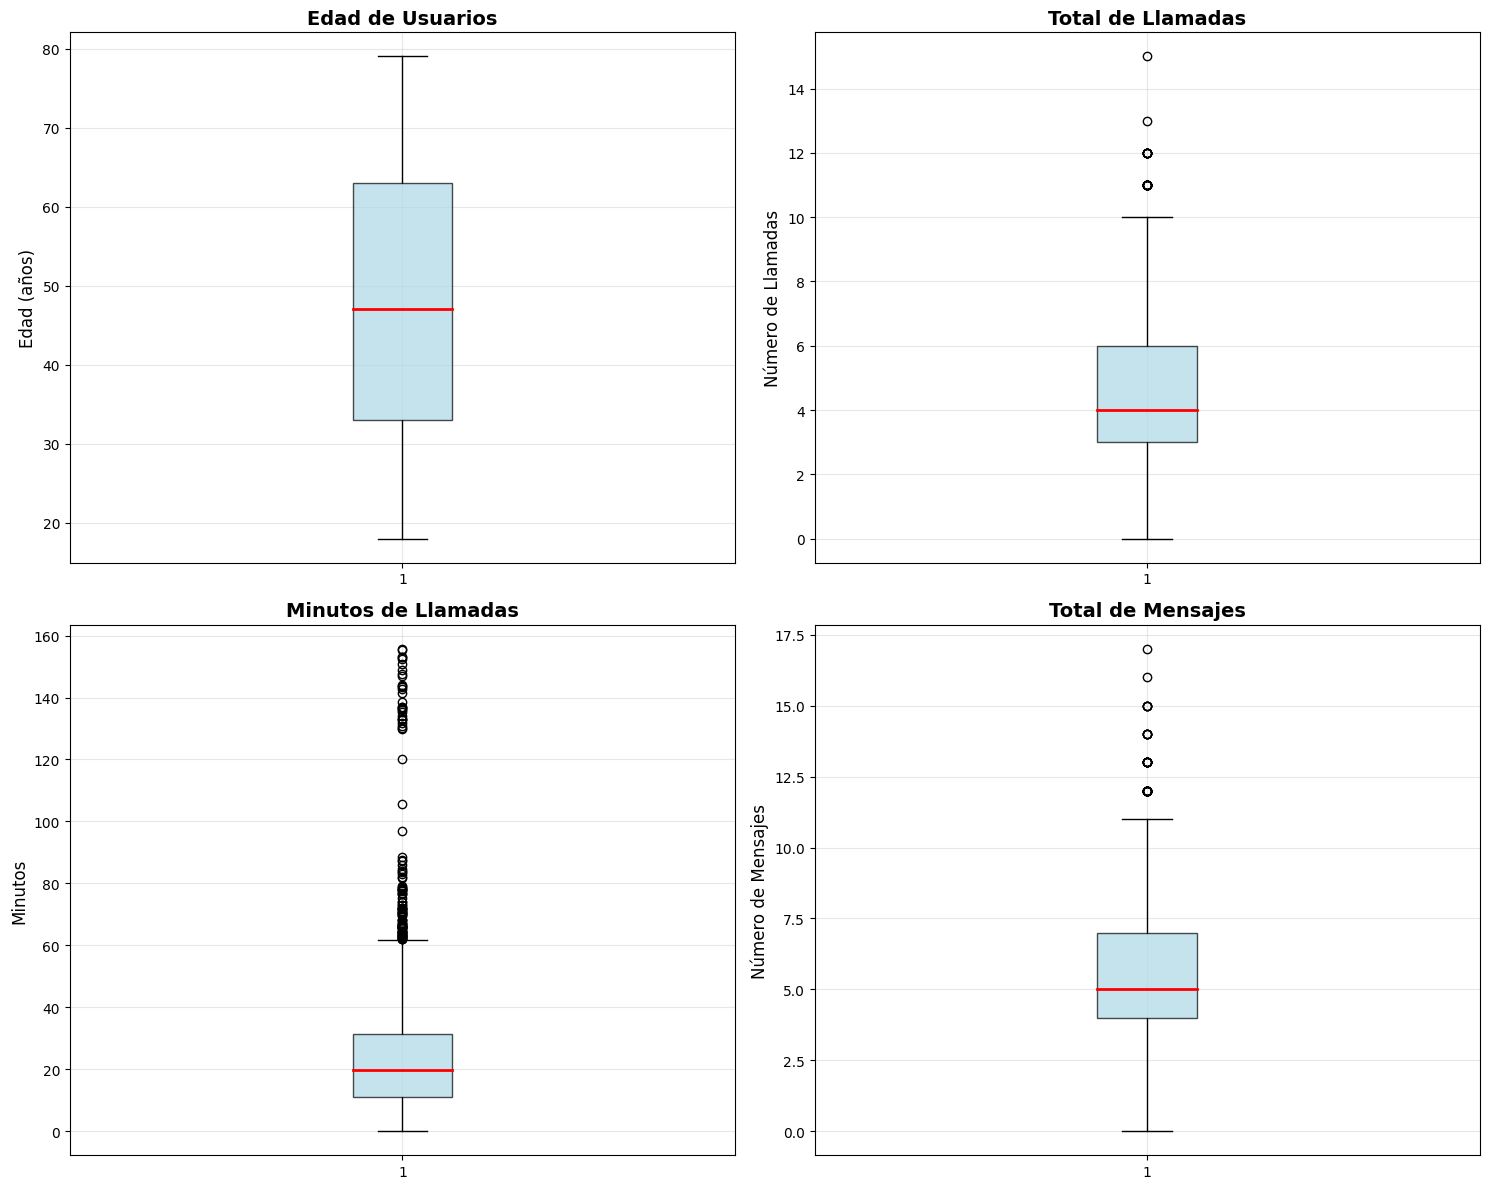

In [106]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

boxplot_config = [
    {'data': users['age'], 'title': 'Edad de Usuarios', 'ylabel': 'Edad (años)'},
    {'data': usage_agg['total_calls'], 'title': 'Total de Llamadas', 'ylabel': 'Número de Llamadas'},
    {'data': usage_agg['total_call_minutes'], 'title': 'Minutos de Llamadas', 'ylabel': 'Minutos'},
    {'data': usage_agg['total_messages'], 'title': 'Total de Mensajes', 'ylabel': 'Número de Mensajes'}
]

# Crear una figura con subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()  # Convertir la matriz 2x2 en un array 1D para facilitar la iteración

# Generar los boxplots usando el bucle for
for i, config in enumerate(boxplot_config):
    # Crear el boxplot en el subplot correspondiente
    axes[i].boxplot(config['data'], patch_artist=True, 
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
    
#Configurar título y etiquetas
    axes[i].set_title(config['title'], fontsize=14, fontweight='bold')
    axes[i].set_ylabel(config['ylabel'], fontsize=12)
    axes[i].grid(True, alpha=0.3)

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [70]:
# Calcular límites con el método IQR
columnas_limites = [
    {'data': users['age'], 'nombre': 'age', 'descripcion': 'Edad de Usuarios'},
    {'data': usage_agg['total_calls'], 'nombre': 'total_calls', 'descripcion': 'Total de Llamadas'},
    {'data': usage_agg['total_call_minutes'], 'nombre': 'total_call_minutes', 'descripcion': 'Minutos de Llamadas'},
    {'data': usage_agg['total_messages'], 'nombre': 'total_messages', 'descripcion': 'Total de Mensajes'}
]

# Calcular límites IQR para cada columna
limites_iqr = {}

for columna in columnas_limites:
    # Obtener los datos
    datos = columna['data']
    nombre = columna['nombre']
    
    # Calcular cuartiles
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1
    
    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_inferiores = (datos < limite_inferior).sum()
    outliers_superiores = (datos > limite_superior).sum()
    total_outliers = outliers_inferiores + outliers_superiores
    
    # Guardar resultados
    limites_iqr[nombre] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'outliers_inferiores': outliers_inferiores,
        'outliers_superiores': outliers_superiores,
        'total_outliers': total_outliers,
        'porcentaje_outliers': (total_outliers / len(datos)) * 100
    }

# Mostrar resultados
for nombre, limites in limites_iqr.items():
    print(f"\n=== {nombre.upper()} ===")
    print(f"Q1 (Percentil 25): {limites['Q1']:.2f}")
    print(f"Q3 (Percentil 75): {limites['Q3']:.2f}")
    print(f"IQR: {limites['IQR']:.2f}")
    print(f"Límite inferior: {limites['limite_inferior']:.2f}")
    print(f"Límite superior: {limites['limite_superior']:.2f}")
    print(f"Outliers inferiores: {limites['outliers_inferiores']}")
    print(f"Outliers superiores: {limites['outliers_superiores']}")
    print(f"Total outliers: {limites['total_outliers']}")
    print(f"Porcentaje de outliers: {limites['porcentaje_outliers']:.2f}%")




=== AGE ===
Q1 (Percentil 25): 33.00
Q3 (Percentil 75): 63.00
IQR: 30.00
Límite inferior: -12.00
Límite superior: 108.00
Outliers inferiores: 0
Outliers superiores: 0
Total outliers: 0
Porcentaje de outliers: 0.00%

=== TOTAL_CALLS ===
Q1 (Percentil 25): 3.00
Q3 (Percentil 75): 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50
Outliers inferiores: 0
Outliers superiores: 30
Total outliers: 30
Porcentaje de outliers: 0.75%

=== TOTAL_CALL_MINUTES ===
Q1 (Percentil 25): 11.12
Q3 (Percentil 75): 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86
Outliers inferiores: 0
Outliers superiores: 109
Total outliers: 109
Porcentaje de outliers: 2.73%

=== TOTAL_MESSAGES ===
Q1 (Percentil 25): 4.00
Q3 (Percentil 75): 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50
Outliers inferiores: 0
Outliers superiores: 46
Total outliers: 46
Porcentaje de outliers: 1.15%


In [78]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
#user_profile[columnas_limites].describe()


# Obtener estadísticas descriptivas
#stats = user_profile[columnas_limites].describe()

# Crear tabla de comparación (completa este código)
#comparacion = pd.DataFrame({
#    'Limite_Superior': [108.00, 10.50, 61.86, 11.50],  # Los límites que calculaste
#    'Valor_Maximo': stats.loc['max'].values,  # Los valores máximos reales
#    'Diferencia': stats.loc['max'].values - [108.00, 10.50, 61.86, 11.50]
#}, index=['AGE', 'TOTAL_CALLS', 'TOTAL_CALL_MINUTES', 'TOTAL_MESSAGES'])

#print(comparacion)

comparacion = pd.DataFrame({
    'Limite_Superior': [108.00, 10.50, 61.86, 11.50],
    'Valor_Maximo': [
        users['age'].max(),
        usage_agg['total_calls'].max(),
        usage_agg['total_call_minutes'].max(),
        usage_agg['total_messages'].max()
    ]
}, index=['AGE', 'TOTAL_CALLS', 'TOTAL_CALL_MINUTES', 'TOTAL_MESSAGES'])

# Calcular la diferencia
comparacion['Diferencia'] = comparacion['Valor_Maximo'] - comparacion['Limite_Superior']
comparacion['Outliers_Detectados'] = [0, 30, 109, 46]  # Los que calculaste antes

print("\n=== COMPARACIÓN LÍMITES vs VALORES MÁXIMOS ===")
print(comparacion)



=== COMPARACIÓN LÍMITES vs VALORES MÁXIMOS ===
                    Limite_Superior  Valor_Maximo  Diferencia  \
AGE                          108.00         79.00      -29.00   
TOTAL_CALLS                   10.50         15.00        4.50   
TOTAL_CALL_MINUTES            61.86        155.69       93.83   
TOTAL_MESSAGES                11.50         17.00        5.50   

                    Outliers_Detectados  
AGE                                   0  
TOTAL_CALLS                          30  
TOTAL_CALL_MINUTES                  109  
TOTAL_MESSAGES                       46  


- edad: mantener o no outliers, porqué?
 Límite Superior: 108.00 | Valor Máximo: 79.00 | Outliers: 0

Decisión: No hay outliers que evaluar
- La edad máxima (79 años) está muy por debajo del límite superior
- Esto indica que todos los valores de edad son razonables y no hay datos anómalos
  
- cant_mensajes: mantener o no outliers, porqué?
Límite Superior: 10.50 | Valor Máximo: 15.00 | Outliers: 30 (0.75%)

Decisión: MANTENER los outliers

¿Por qué mantenerlos?
- La diferencia es pequeña (4.5 llamadas)
- 15 llamadas máximo es perfectamente realista en telecomunicaciones
- Solo 0.75% de outliers (muy bajo porcentaje)
- Razón de negocio: Usuarios heavy pueden hacer 15+ llamadas fácilmente

- cant_llamadas: mantener o no outliers, porqué?
Límite Superior: 11.50 | Valor Máximo: 17.00 | Outliers: 46 (1.15%)

Decisión: MANTENER los outliers

¿Por qué mantenerlos?
- 17 mensajes es completamente normal
- Diferencia pequeña (5.5 mensajes)
- 1.15% de outliers es muy bajo
- Razón práctica: Muchas personas envían 15-20 mensajes fácilmente
 
- cant_minutos_llamada: mantener o no outliers, porqué?
  Límite Superior: 61.86 | Valor Máximo: 155.69 | Outliers: 109 (2.73%)

Decisión: MANTENER los outliers

¿Por qué mantenerlos? (Paso a paso):

Paso 1 - Análisis de realismo:
- 155.69 minutos = 2.6 horas de llamadas
- Esto es totalmente realista para usuarios business o familiares

Paso 2 - Análisis de diferencia:
- Diferencia de 93.83 minutos parece grande, PERO...
- En telecomunicaciones, la variabilidad en minutos es naturalmente alta

Paso 3 - Análisis de porcentaje:
- 2.73% de outliers es un porcentaje razonable
- No indica errores de datos, sino comportamiento real de usuarios heavy

Paso 4 - Valor de negocio:
- Estos usuarios son muy valiosos (alto consumo = alta facturación)
- Eliminarlos sería un error estratégico

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [110]:
# Crear columna grupo_uso
#df['grupo_uso'] = pd.cut(df['variable_de_uso'], 
#                        bins=[valor1, valor2, valor3, valor4], 
#                        labels=['Bajo', 'Moderado', 'Alto'])
# Crear score de uso combinado (normalizado)
usage_agg['score_uso'] = (usage_agg['total_messages'] / usage_agg['total_messages'].max()) + \
                         (usage_agg['total_call_minutes'] / usage_agg['total_call_minutes'].max())

usage_agg['grupo_uso'] = pd.cut(usage_agg['score_uso'], 
                               bins=[usage_agg['score_uso'].min()-0.001, 
                                     usage_agg['score_uso'].quantile(0.33),
                                     usage_agg['score_uso'].quantile(0.66), 
                                     usage_agg['score_uso'].max()],
                               labels=['Bajo', 'Moderado', 'Alto'])

# Verificar la distribución de grupos
print(usage_agg['grupo_uso'].value_counts())
print("\nEstadísticas del score_uso por grupo:")
print(usage_agg.groupby('grupo_uso')['score_uso'].describe())

Alto        1360
Bajo        1320
Moderado    1319
Name: grupo_uso, dtype: int64

Estadísticas del score_uso por grupo:
            count      mean       std       min       25%       50%       75%  \
grupo_uso                                                                       
Bajo       1320.0  0.291931  0.071650  0.011883  0.243964  0.306718  0.352910   
Moderado   1319.0  0.457698  0.039559  0.389190  0.422856  0.458910  0.490983   
Alto       1360.0  0.668670  0.140599  0.528278  0.572078  0.630501  0.720287   

                max  
grupo_uso            
Bajo       0.388986  
Moderado   0.528120  
Alto       1.527678  


In [111]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [112]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = user_profile['age'].apply(
    lambda x: 'Joven' if x < 30 
    else 'Adulto' if x < 60 
    else 'Adulto Mayor'
)

# Verificar los resultados
print("Distribución por grupos de edad:")
print(user_profile['grupo_edad'].value_counts())
print(f"\nTotal de usuarios: {len(user_profile)}")

# Estadísticas detalladas por grupo
print("\nEstadísticas de edad por grupo:")
print(user_profile.groupby('grupo_edad')['age'].describe())

# Verificar algunas filas para confirmar la segmentación
print("\nPrimeras 10 filas con edad y grupo_edad:")
print(user_profile[['age', 'grupo_edad']].head(10))

Distribución por grupos de edad:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

Total de usuarios: 4000

Estadísticas de edad por grupo:
               count       mean       std   min   25%   50%   75%   max
grupo_edad                                                             
Adulto        2018.0  44.346383  8.614157  30.0  37.0  45.0  51.0  59.0
Adulto Mayor  1222.0  69.617840  5.833376  60.0  65.0  70.0  75.0  79.0
Joven          760.0  23.585526  3.501259  18.0  20.0  24.0  27.0  29.0

Primeras 10 filas con edad y grupo_edad:
    age    grupo_edad
0  38.0        Adulto
1  53.0        Adulto
2  57.0        Adulto
3  69.0  Adulto Mayor
4  63.0  Adulto Mayor
5  61.0  Adulto Mayor
6  39.0        Adulto
7  70.0  Adulto Mayor
8  76.0  Adulto Mayor
9  47.0        Adulto


In [113]:

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

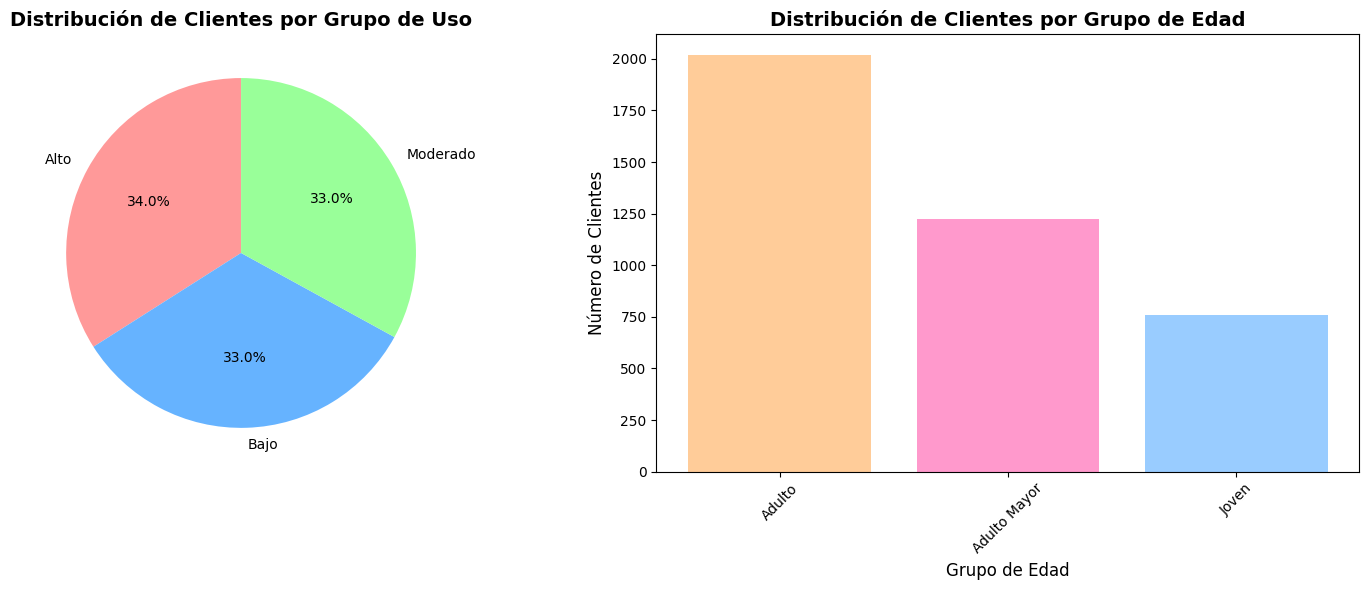

=== ESTADÍSTICAS DE SEGMENTACIÓN ===

1. GRUPO DE USO:
Total usuarios analizados: 3999
Alto        1360
Bajo        1320
Moderado    1319
Name: grupo_uso, dtype: int64
Porcentajes: Alto        34.0
Bajo        33.0
Moderado    33.0
Name: grupo_uso, dtype: float64%

2. GRUPO DE EDAD:
Total usuarios analizados: 4000
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64
Porcentajes: Adulto          50.4
Adulto Mayor    30.6
Joven           19.0
Name: grupo_edad, dtype: float64%


In [115]:
# Visualización de los segmentos por uso
#sns.countplot(...)

#plt.show()
# Configurar el estilo de los gráficos
plt.style.use('default')
sns.set_palette("husl")

# Crear figura con subplots (2 gráficos lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# GRÁFICO 1: Distribución de grupo_uso
grupo_uso_counts = usage_agg['grupo_uso'].value_counts()
axes[0].pie(grupo_uso_counts.values, 
           labels=grupo_uso_counts.index, 
           autopct='%1.1f%%',
           startangle=90,
           colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[0].set_title('Distribución de Clientes por Grupo de Uso', 
                  fontsize=14, fontweight='bold')

# GRÁFICO 2: Distribución de grupo_edad  
grupo_edad_counts = user_profile['grupo_edad'].value_counts()
axes[1].bar(grupo_edad_counts.index, 
           grupo_edad_counts.values,
           color=['#ffcc99', '#ff99cc', '#99ccff'])
axes[1].set_title('Distribución de Clientes por Grupo de Edad', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupo de Edad', fontsize=12)
axes[1].set_ylabel('Número de Clientes', fontsize=12)

# Rotar etiquetas del eje x para mejor legibilidad
axes[1].tick_params(axis='x', rotation=45)

# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

# Imprimir estadísticas complementarias
print("=== ESTADÍSTICAS DE SEGMENTACIÓN ===")
print("\n1. GRUPO DE USO:")
print(f"Total usuarios analizados: {len(usage_agg)}")
print(grupo_uso_counts)
print(f"Porcentajes: {(grupo_uso_counts/len(usage_agg)*100).round(1)}%")

print("\n2. GRUPO DE EDAD:")
print(f"Total usuarios analizados: {len(user_profile)}")
print(grupo_edad_counts)
print(f"Porcentajes: {(grupo_edad_counts/len(user_profile)*100).round(1)}%")

In [ ]:
# Visualización de los segmentos por edad



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`